In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
import matplotlib.pyplot as plt
import seaborn as sns


file_path = '/content/drive/MyDrive/HALE-Data/cleaned_dataset.csv'
data = pd.read_csv(file_path)


print(data.columns)

Index(['Period', 'ParentLocation', 'Location', 'Dim1', 'HALE_Birth', 'HALE_60',
       'infant mortality rate (between birth and 11 months per 1000 live births)',
       'Age-standardized suicide rates (per 100 000 population)',
       'Alcohol, total per capita (15+ years) consumption (in litres of pure alcohol) (SDG Indicator 3.5.2)',
       'Probability of dying between the exact ages 30 and 70 years from cardiovascular diseases, cancer, diabetes, or chronic respiratory diseases (SDG 3.4.1)',
       'Estimates of rate of homicides (per 100 000 population)',
       'Mean Total Cholesterol (crude estimate)',
       'Prevalence of insufficient physical activity among adults aged 18+ years (age-standardized estimate) (%)',
       'Prevalence of obesity among adults, BMI ³ 30 (age-standardized estimate) (%)',
       'Prevalence of raised blood pressure among adults aged 30-79 years'],
      dtype='object')


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
missing_values = data.isnull().sum()
print("Missing values:")
print(missing_values)

Missing values:
Period                                                                                                                                                     0
ParentLocation                                                                                                                                             0
Location                                                                                                                                                   0
Dim1                                                                                                                                                       0
HALE_Birth                                                                                                                                                 0
HALE_60                                                                                                                                                    0
infant mortality rate (between birth and 1

In [ ]:
# Identify non-numeric columns to be one-hot encoded
non_numeric_columns = ['ParentLocation', 'Location', 'Dim1']

# One-hot encode non-numeric columns
data = pd.get_dummies(data, columns=non_numeric_columns)

In [ ]:
#percentage-based columns
percentage_columns = [
    'Prevalence of insufficient physical activity among adults aged 18+ years (age-standardized estimate) (%)',
    'Prevalence of obesity among adults, BMI ³ 30 (age-standardized estimate) (%)',
    'Prevalence of raised blood pressure among adults aged 30-79 years'
]

#absolute numeric columns (for Z-score normalization)
absolute_columns = [
    'HALE_Birth',
    'HALE_60',
    'infant mortality rate (between birth and 11 months per 1000 live births)',
    'Age-standardized suicide rates (per 100 000 population)',
    'Alcohol, total per capita (15+ years) consumption (in litres of pure alcohol) (SDG Indicator 3.5.2)',
    'Probability of dying between the exact ages 30 and 70 years from cardiovascular diseases, cancer, diabetes, or chronic respiratory diseases (SDG 3.4.1)',
    'Estimates of rate of homicides (per 100 000 population)',
    'Mean Total Cholesterol (crude estimate)'
]

In [ ]:
# Scale percentage columns to [0, 1] by dividing by 100
data[percentage_columns] = data[percentage_columns] / 100

# Apply Z-score standardization for absolute numeric columns
scaler = StandardScaler()
data[absolute_columns] = scaler.fit_transform(data[absolute_columns])

In [ ]:

data.to_csv('/content/drive/MyDrive/HALE-Data/normalized.csv', index=False)

print("Normalization and encoding complete!")

Normalization and encoding complete!


In [ ]:
normalized_data = pd.read_csv('/content/drive/MyDrive/HALE-Data/normalized.csv')


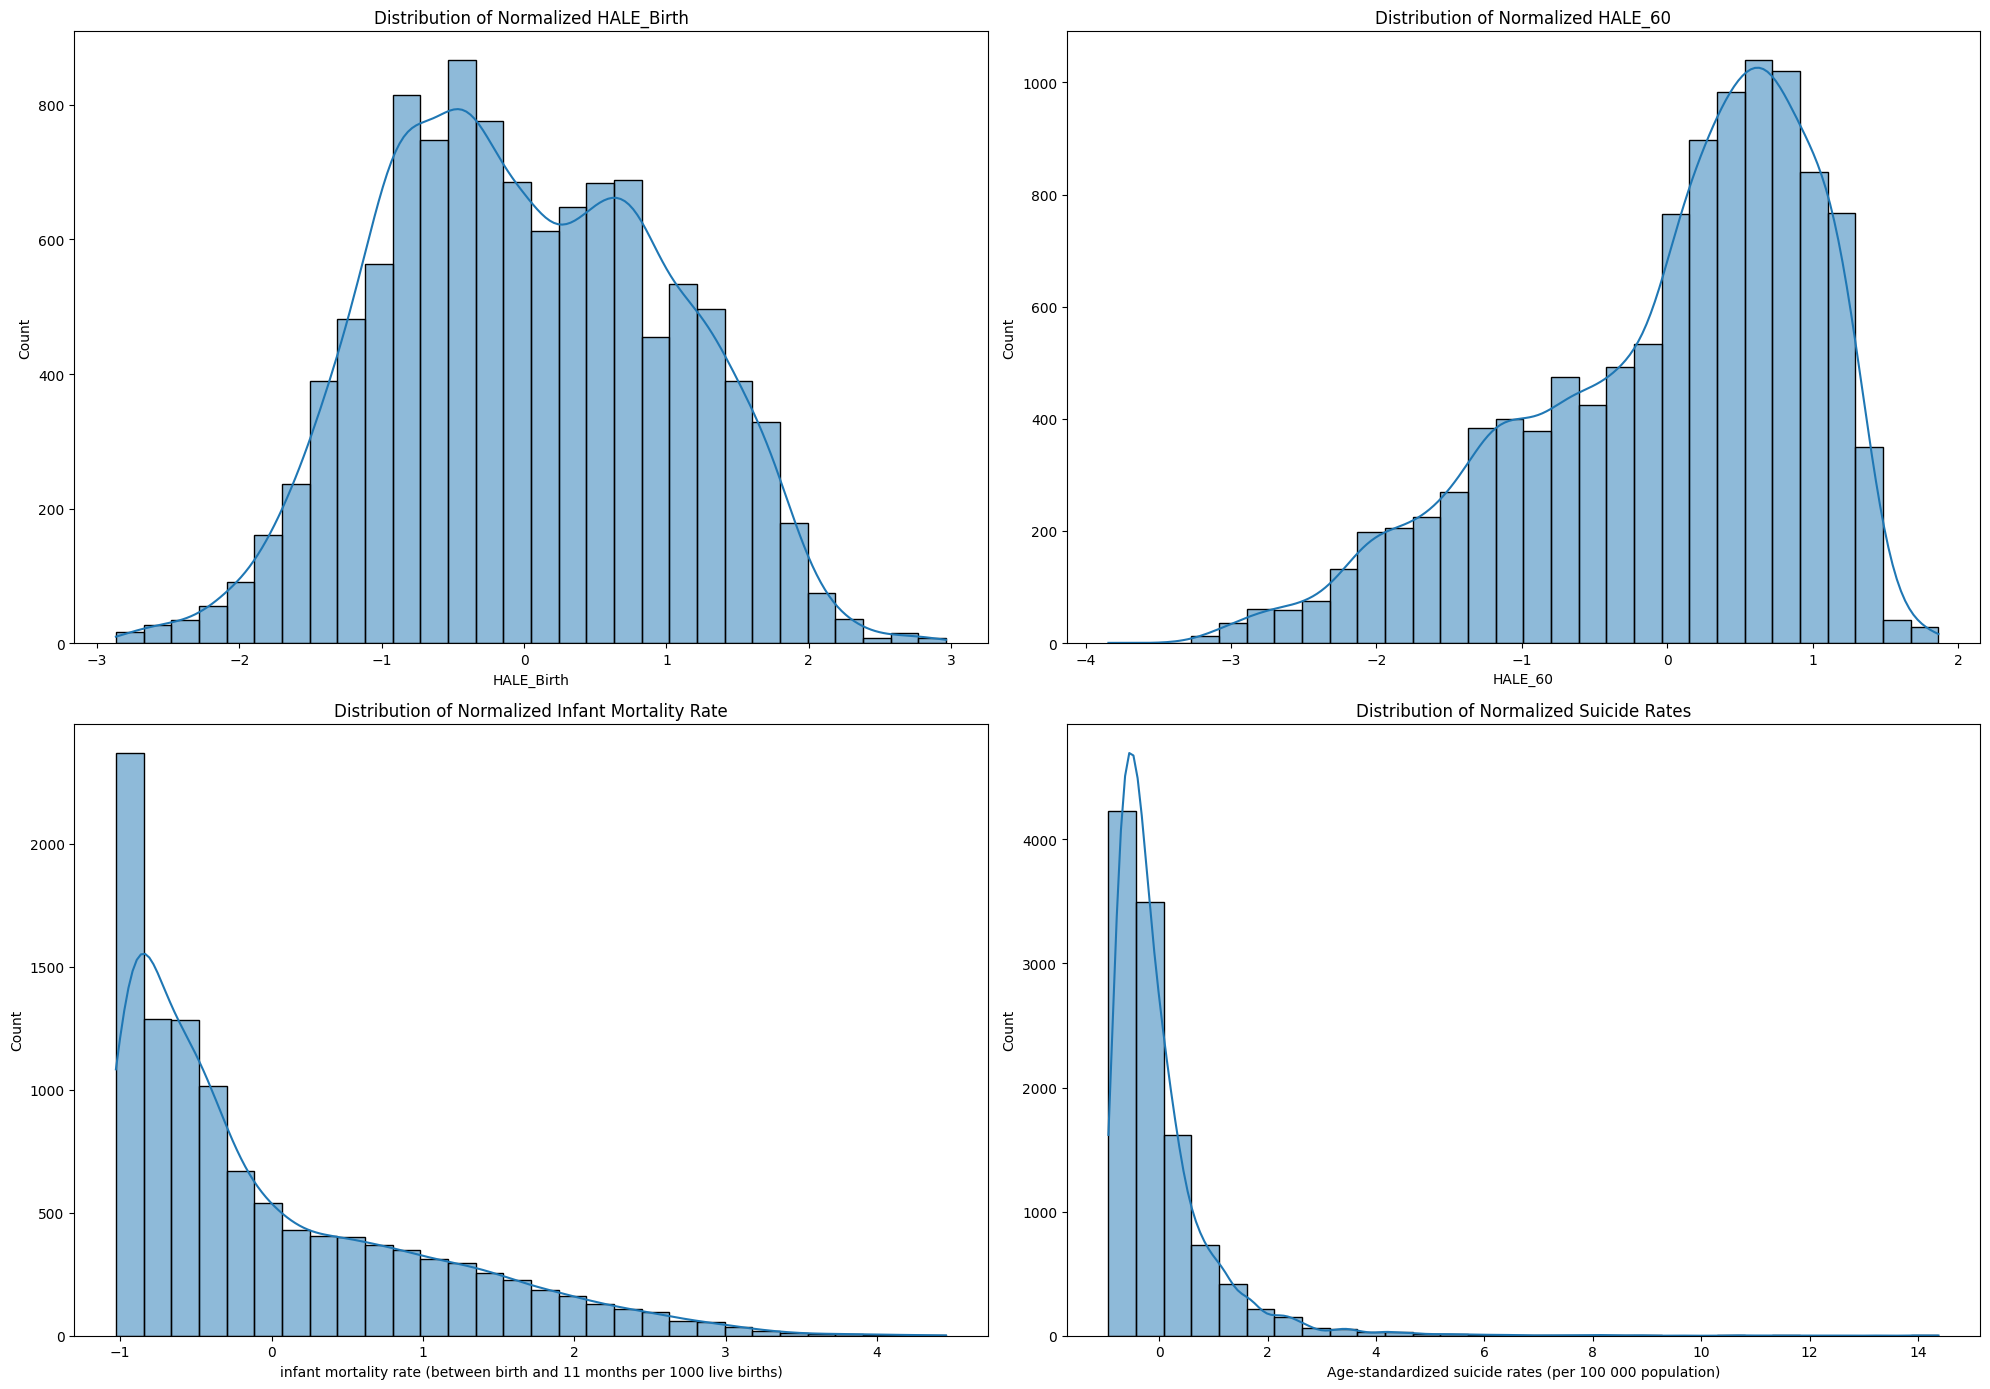

In [ ]:

plt.figure(figsize=( 20 , 14))

# Histogram for normalized HALE_Birth
plt.subplot(2, 2, 1)
sns.histplot(normalized_data['HALE_Birth'], bins=30, kde=True)
plt.title('Distribution of Normalized HALE_Birth')

# Histogram for normalized HALE_60
plt.subplot(2, 2, 2)
sns.histplot(normalized_data['HALE_60'], bins=30, kde=True)
plt.title('Distribution of Normalized HALE_60')

# Histogram for normalized infant mortality rate
plt.subplot(2, 2, 3)
sns.histplot(normalized_data['infant mortality rate (between birth and 11 months per 1000 live births)'], bins=30, kde=True)
plt.title('Distribution of Normalized Infant Mortality Rate')

# Histogram for normalized suicide rates
plt.subplot(2, 2, 4)
sns.histplot(normalized_data['Age-standardized suicide rates (per 100 000 population)'], bins=30, kde=True)
plt.title('Distribution of Normalized Suicide Rates')

plt.tight_layout()
plt.show()